# Least Squares: Fitting What Doesn't Exactly Fit

Real measurements are noisy, so $Ax = b$ usually has no exact solution. Least squares finds the $x$ that gets closest -- and "closest" turns out to mean projecting $b$ onto the column space of $A$. This notebook builds that solver from the normal equations, then uses it on Anscombe's quartet to show why you should always plot your data.

## The math

We want the $x$ minimizing $\|Ax - b\|^2$. Setting the gradient to zero gives the **normal equations**:

$$A^TA\,x = A^Tb$$

Geometrically, $Ax$ can only ever land somewhere in the column space of $A$. The best we can do is pick the point in that column space closest to $b$ -- i.e., the orthogonal projection of $b$ onto $\text{col}(A)$. We can check this after solving: the residual $b - A\hat{x}$ should be orthogonal to every column of $A$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from linalg_playground.least_squares import fit_least_squares, polynomial_design_matrix

Fitted: y = 3.08 x + 1.46  (true: y = 3.00 x + 2.00)
Residual dot columns of A (should be ~0): [-1.90070182e-13 -1.35003120e-13]


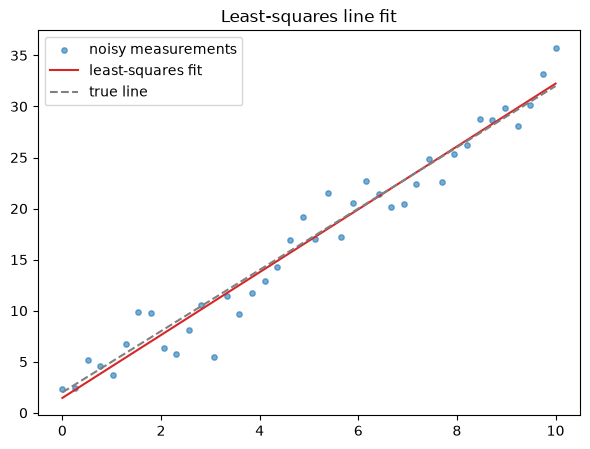

In [2]:
rng = np.random.default_rng(0)
x = np.linspace(0, 10, 40)
y_true = 3.0 * x + 2.0
y = y_true + rng.normal(scale=2.5, size=x.shape)

A = np.column_stack([np.ones_like(x), x])
coeffs = fit_least_squares(A, y)
print(f"Fitted: y = {coeffs[1]:.2f} x + {coeffs[0]:.2f}  (true: y = 3.00 x + 2.00)")

residual = y - A @ coeffs
print("Residual dot columns of A (should be ~0):", A.T @ residual)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x, y, s=15, alpha=0.6, label="noisy measurements")
ax.plot(x, A @ coeffs, color="tab:red", label="least-squares fit")
ax.plot(x, y_true, color="gray", linestyle="--", label="true line")
ax.legend()
ax.set_title("Least-squares line fit")
plt.show()

## From Jacobian to Hessian: one Newton step

For the line-fit parameters $c = [c_0, c_1]^T$, define the residual and squared-error loss as

$$r(c) = Ac - y, \qquad L(c) = \frac{1}{2}\|r(c)\|^2.$$

Because $r(c)$ is linear in $c$, its Jacobian is constant:

$$J = \frac{\partial r}{\partial c} = A.$$

Applying the chain rule gives

$$\nabla L(c) = J^T r(c), \qquad H = \nabla^2 L(c) = J^T J = A^T A.$$

For a nonlinear residual, $J^T J$ is generally the Gauss–Newton approximation to the Hessian. Here it is the **exact** Hessian because every second derivative of the linear residual is zero. The quadratic loss therefore reaches its minimum in one Newton step (ignoring numerical round-off).

In [ ]:
c_start = np.array([0.0, 0.0])
r_start = A @ c_start - y
J = A
gradient = J.T @ r_start
H = J.T @ J

c_new = c_start - np.linalg.solve(H, gradient)
r_new = A @ c_new - y

print("start coefficients:", c_start)
print("after one Newton step:", c_new)
print("normal-equation solution:", coeffs)
print(f"loss: {0.5 * r_start @ r_start:.3f} -> {0.5 * r_new @ r_new:.3f}")

# The Newton update and the closed-form least-squares solution agree.
assert np.allclose(c_new, coeffs)
assert np.allclose(H, A.T @ A)
assert np.linalg.norm(J.T @ r_new) < 1e-8

# Visualize the quadratic loss surface in (intercept, slope) space.
intercepts = np.linspace(min(c_start[0], coeffs[0]) - 1,
                         max(c_start[0], coeffs[0]) + 1, 120)
slopes = np.linspace(min(c_start[1], coeffs[1]) - 1,
                     max(c_start[1], coeffs[1]) + 1, 120)
C0, C1 = np.meshgrid(intercepts, slopes)
predictions = C0[..., None] + C1[..., None] * x
losses = 0.5 * np.sum((predictions - y) ** 2, axis=-1)

fig, ax = plt.subplots(figsize=(7, 5))
contours = ax.contour(C0, C1, losses, levels=20)
ax.clabel(contours, inline=True, fontsize=7)
ax.scatter(*c_start, color="tab:orange", s=60, label="start")
ax.scatter(*c_new, color="tab:red", s=60, label="one Newton step")
ax.annotate("", xy=c_new, xytext=c_start,
            arrowprops={"arrowstyle": "->", "color": "black"})
ax.set_xlabel("intercept $c_0$")
ax.set_ylabel("slope $c_1$")
ax.set_title("One Newton step on the least-squares loss")
ax.legend()
plt.show()

Fitted polynomial coefficients (c0, c1, c2): [ 0.87884445 -1.04151661  0.52330655]


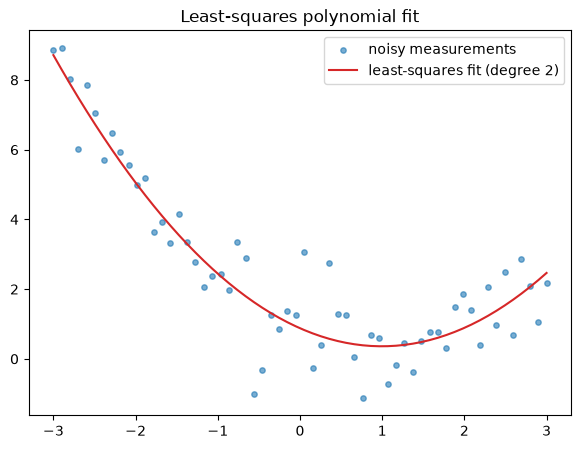

In [3]:
rng = np.random.default_rng(1)
x2 = np.linspace(-3, 3, 60)
y2_true = 0.5 * x2 ** 2 - x2 + 1
y2 = y2_true + rng.normal(scale=1.0, size=x2.shape)

A2 = polynomial_design_matrix(x2, degree=2)
coeffs2 = fit_least_squares(A2, y2)
print("Fitted polynomial coefficients (c0, c1, c2):", coeffs2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(x2, y2, s=15, alpha=0.6, label="noisy measurements")
order = np.argsort(x2)
ax.plot(x2[order], (A2 @ coeffs2)[order], color="tab:red", label="least-squares fit (degree 2)")
ax.legend()
ax.set_title("Least-squares polynomial fit")
plt.show()

## Anscombe's quartet

These four datasets were constructed by Francis Anscombe (1973) to have nearly identical summary statistics -- including the exact same least-squares fit -- despite looking completely different. Least squares alone can't tell them apart; only plotting can.

slope=0.500 intercept=3.000
slope=0.500 intercept=3.001
slope=0.500 intercept=3.002
slope=0.500 intercept=3.002


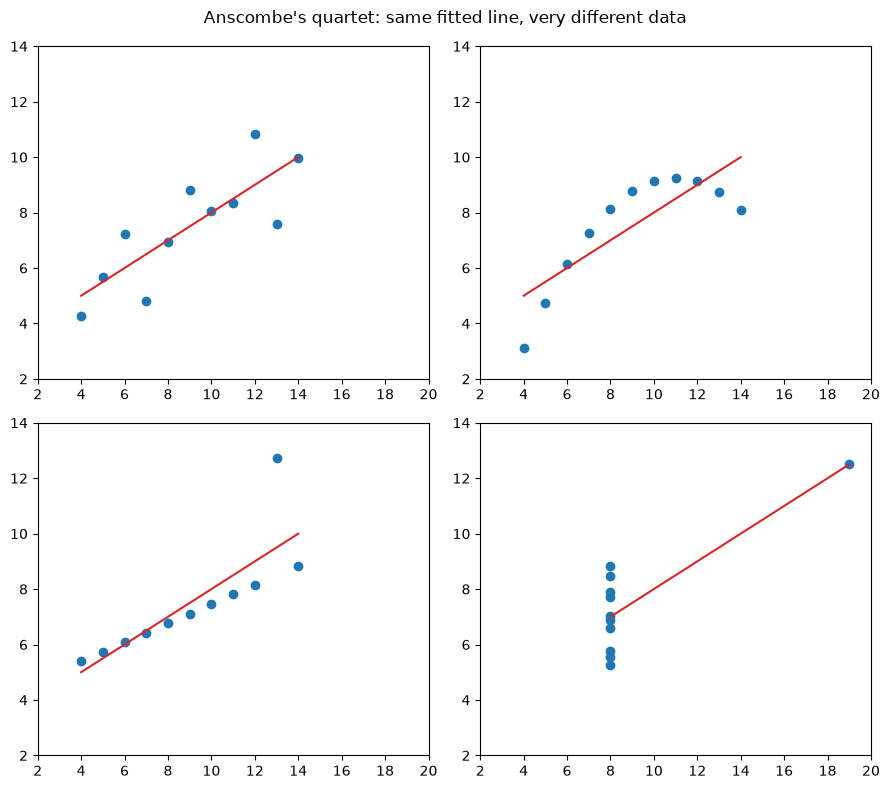

In [4]:
anscombe_x1 = np.array([10, 8, 13, 9, 11, 14, 6, 4, 12, 7, 5], dtype=float)
anscombe_y1 = np.array([8.04, 6.95, 7.58, 8.81, 8.33, 9.96, 7.24, 4.26, 10.84, 4.82, 5.68])
anscombe_x2 = anscombe_x1.copy()
anscombe_y2 = np.array([9.14, 8.14, 8.74, 8.77, 9.26, 8.10, 6.13, 3.10, 9.13, 7.26, 4.74])
anscombe_x3 = anscombe_x1.copy()
anscombe_y3 = np.array([7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73])
anscombe_x4 = np.array([8, 8, 8, 8, 8, 8, 8, 19, 8, 8, 8], dtype=float)
anscombe_y4 = np.array([6.58, 5.76, 7.71, 8.84, 8.47, 7.04, 5.25, 12.50, 5.56, 7.91, 6.89])

datasets = [
    (anscombe_x1, anscombe_y1),
    (anscombe_x2, anscombe_y2),
    (anscombe_x3, anscombe_y3),
    (anscombe_x4, anscombe_y4),
]

fig, axes = plt.subplots(2, 2, figsize=(9, 8))
for ax, (xs, ys) in zip(axes.ravel(), datasets):
    A_i = np.column_stack([np.ones_like(xs), xs])
    coeffs_i = fit_least_squares(A_i, ys)
    print(f"slope={coeffs_i[1]:.3f} intercept={coeffs_i[0]:.3f}")
    order_i = np.argsort(xs)
    ax.scatter(xs, ys)
    ax.plot(xs[order_i], (A_i @ coeffs_i)[order_i], color="tab:red")
    ax.set_xlim(2, 20)
    ax.set_ylim(2, 14)
fig.suptitle("Anscombe's quartet: same fitted line, very different data")
plt.tight_layout()
plt.show()

## Takeaway

The normal equations turn "find the best-fit line" into a small linear system. But the same fitted line can come from very different underlying data -- the fit doesn't know it's being fooled. Always look at the plot, not just the coefficients.